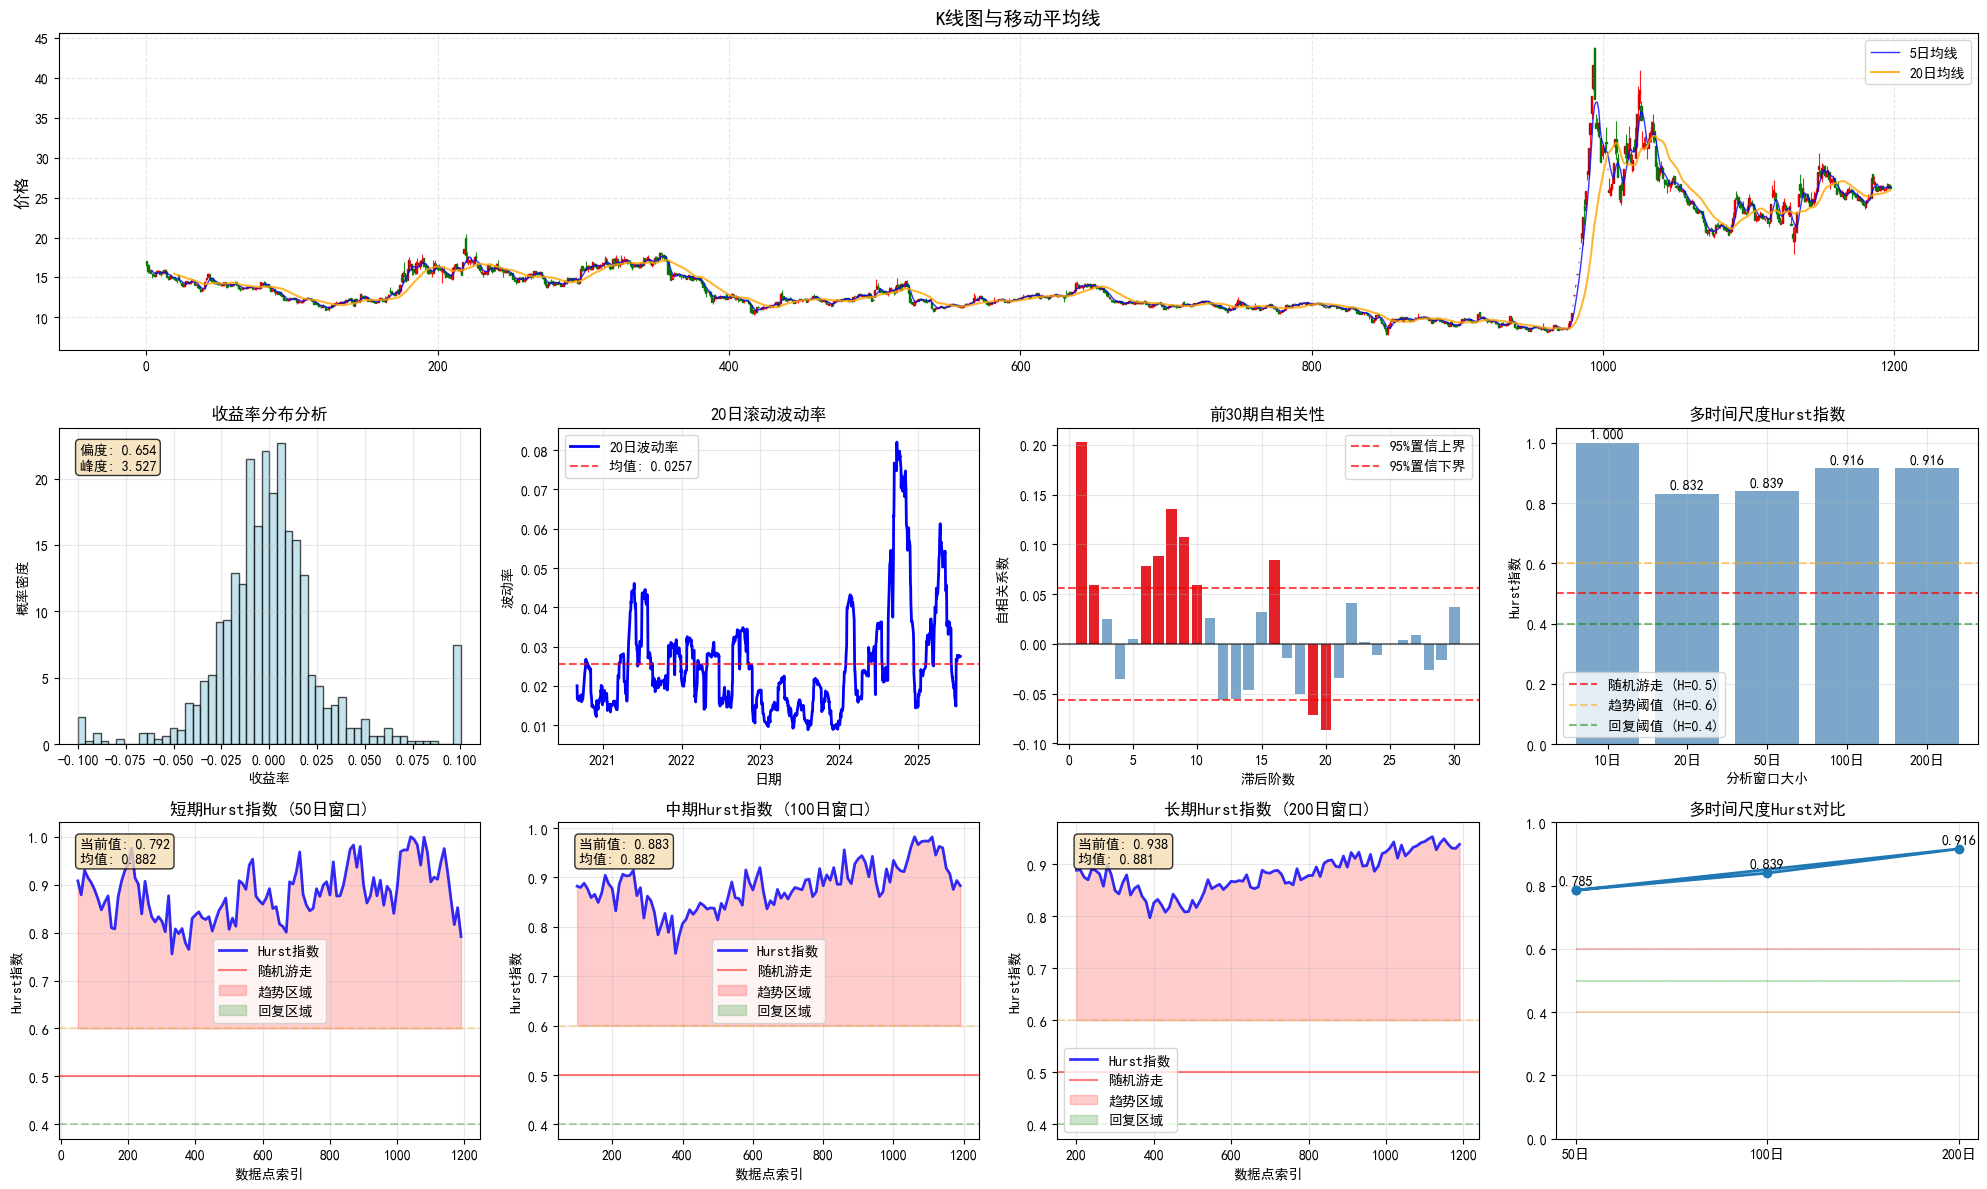


                 市场统计分析摘要
数据期间: 2020-08-06 00:00:00 到 2025-07-16 00:00:00
数据点数: 1198
价格范围: 7.78 - 43.80
最终收盘价: 26.21

收益率统计:
平均日收益率: 0.0812%
收益率标准差: 2.9667%
偏度: 0.6538
峰度: 3.5268

自相关性:
1期自相关: 0.2027
5期自相关: 0.0046

多时间尺度Hurst分析:
50日窗口: 0.7853 (趋势性)
100日窗口: 0.8394 (趋势性)
200日窗口: 0.9162 (趋势性)


In [2]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from scipy.stats import kurtosis, skew
import pandas as pd

def comprehensive_statistical_analysis_plot(df):
    """
    综合统计分析图表：K线图 + 统计指标 + 多时间尺度Hurst分析
    """
    # 设置中文字体
    plt.rcParams['font.sans-serif'] = ['SimHei']
    plt.rcParams['axes.unicode_minus'] = False
    
    # 创建复杂的网格布局
    fig = plt.figure(figsize=(20, 12))
    gs = gridspec.GridSpec(3, 4, figure=fig)
    
    # 主K线图区域（占用1行）
    ax_kline = fig.add_subplot(gs[0, :])
    
    # 统计指标子图区域
    ax_returns = fig.add_subplot(gs[1, 0])  # 收益率分布
    ax_volatility = fig.add_subplot(gs[1, 1])  # 波动率分析
    ax_autocorr = fig.add_subplot(gs[1, 2])  # 自相关性
    ax_multi_hurst = fig.add_subplot(gs[1, 3])  # 多时间尺度Hurst
    
    # 多时间框架Hurst分析区域（占用底部1行）
    ax_hurst_short = fig.add_subplot(gs[2, 0])  # 短期Hurst
    ax_hurst_medium = fig.add_subplot(gs[2, 1])  # 中期Hurst  
    ax_hurst_long = fig.add_subplot(gs[2, 2])  # 长期Hurst
    ax_hurst_comparison = fig.add_subplot(gs[2, 3])  # Hurst对比
    
    # 1. 绘制主K线图
    plot_kline(ax_kline, df)
    
    # 2. 计算并绘制统计指标
    calculate_and_plot_statistics(ax_returns, ax_volatility, ax_autocorr, ax_multi_hurst, df)
    
    # 3. 多时间尺度Hurst分析
    plot_multi_scale_hurst_analysis(ax_hurst_short, ax_hurst_medium, ax_hurst_long, ax_hurst_comparison, df)
    
    plt.tight_layout()
    plt.show()
    
    # 4. 打印统计分析结果
    print_statistical_summary(df)

def plot_kline(ax, df):
    """绘制K线图"""
    # 绘制K线
    x = np.arange(len(df))
    opens = df['open'].values
    highs = df['high'].values
    lows = df['low'].values
    closes = df['close'].values
    
    # 分离阳线和阴线
    up_indices = closes >= opens
    down_indices = closes < opens
    
    # 阳线 - 红色
    if np.any(up_indices):
        up_x = x[up_indices]
        up_highs = highs[up_indices]
        up_lows = lows[up_indices]
        up_opens = opens[up_indices]
        up_closes = closes[up_indices]
        
        ax.vlines(up_x, up_lows, up_highs, color='red', linewidth=0.8, alpha=0.9)
        ax.bar(up_x, up_closes - up_opens, 0.8, up_opens, 
               color='red', edgecolor='darkred', alpha=0.9)
    
    # 阴线 - 绿色
    if np.any(down_indices):
        down_x = x[down_indices]
        down_highs = highs[down_indices]
        down_lows = lows[down_indices]
        down_opens = opens[down_indices]
        down_closes = closes[down_indices]
        
        ax.vlines(down_x, down_lows, down_highs, color='green', linewidth=0.8, alpha=0.9)
        ax.bar(down_x, down_closes - down_opens, 0.8, down_opens, 
               color='green', edgecolor='darkgreen', alpha=0.9)
    
    # 添加移动平均线
    ma_short = df['close'].rolling(window=5).mean()
    ma_long = df['close'].rolling(window=20).mean()
    ax.plot(x, ma_short, 'b-', linewidth=1, alpha=0.8, label='5日均线')
    ax.plot(x, ma_long, 'orange', linewidth=1.5, alpha=0.8, label='20日均线')
    
    ax.set_title('K线图与移动平均线', fontsize=14, fontweight='bold')
    ax.set_ylabel('价格', fontsize=12)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.3)

def calculate_and_plot_statistics(ax_returns, ax_volatility, ax_autocorr, ax_multi_hurst, df):
    """计算并绘制统计指标"""
    
    # 计算收益率
    returns = df['close'].pct_change().dropna()
    
    # 1. 收益率分布分析（简化版）
    plot_returns_distribution_simple(ax_returns, returns)
    
    # 2. 波动率分析
    plot_volatility_analysis(ax_volatility, returns)
    
    # 3. 自相关性分析
    plot_autocorrelation_analysis(ax_autocorr, returns)
    
    # 4. 多时间尺度Hurst概览
    plot_multi_hurst_overview(ax_multi_hurst, returns)

def plot_returns_distribution_simple(ax, returns):
    """简化的收益率分布图"""
    # 基本统计量
    skewness = skew(returns)
    kurt = kurtosis(returns)
    
    # 绘制直方图
    n, bins, patches = ax.hist(returns, bins=50, density=True, alpha=0.7, 
                              color='lightblue', edgecolor='black')
    
    # 添加统计信息
    ax.text(0.05, 0.95, f'偏度: {skewness:.3f}\n峰度: {kurt:.3f}',
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    ax.set_title('收益率分布分析', fontweight='bold')
    ax.set_xlabel('收益率')
    ax.set_ylabel('概率密度')
    ax.grid(True, alpha=0.3)

def plot_volatility_analysis(ax, returns, window=20):
    """绘制波动率分析图"""
    # 计算滚动波动率
    volatility = returns.rolling(window=window).std()
    
    # 绘制波动率
    ax.plot(volatility.index, volatility, color='blue', linewidth=2, label=f'{window}日波动率')
    ax.axhline(volatility.mean(), color='red', linestyle='--', alpha=0.7, 
               label=f'均值: {volatility.mean():.4f}')
    
    ax.set_title(f'{window}日滚动波动率', fontweight='bold')
    ax.set_xlabel('日期')
    ax.set_ylabel('波动率')
    ax.legend()
    ax.grid(True, alpha=0.3)

def plot_autocorrelation_analysis(ax, returns, max_lag=30):
    """绘制自相关性分析图"""
    # 计算自相关系数
    lags = range(1, max_lag + 1)
    autocorrs = [returns.autocorr(lag=lag) for lag in lags]
    
    # 绘制自相关图
    bars = ax.bar(lags, autocorrs, alpha=0.7, color='steelblue')
    
    # 添加置信区间（95%）
    conf_int = 1.96 / np.sqrt(len(returns))
    ax.axhline(conf_int, color='red', linestyle='--', alpha=0.7, label='95%置信上界')
    ax.axhline(-conf_int, color='red', linestyle='--', alpha=0.7, label='95%置信下界')
    ax.axhline(0, color='black', linestyle='-', alpha=0.5)
    
    # 标记显著的自相关
    significant_lags = [lag for lag, acf_val in zip(lags, autocorrs) 
                       if abs(acf_val) > conf_int]
    for lag in significant_lags:
        ax.bar(lag, autocorrs[lag-1], color='red', alpha=0.8)
    
    ax.set_title(f'前{max_lag}期自相关性', fontweight='bold')
    ax.set_xlabel('滞后阶数')
    ax.set_ylabel('自相关系数')
    ax.legend()
    ax.grid(True, alpha=0.3)

def plot_multi_hurst_overview(ax, returns):
    """多时间尺度Hurst概览"""
    # 计算不同时间尺度的Hurst指数
    time_scales = [10, 20, 50, 100, 200]
    hurst_values = []
    
    for scale in time_scales:
        if len(returns) >= scale * 2:  # 确保有足够数据
            hurst_val = calculate_hurst(returns[-scale*2:])  # 使用最近数据
            hurst_values.append(hurst_val)
        else:
            hurst_values.append(np.nan)
    
    # 过滤有效值
    valid_scales = [s for s, h in zip(time_scales, hurst_values) if not np.isnan(h)]
    valid_hurst = [h for h in hurst_values if not np.isnan(h)]
    
    if valid_hurst:
        # 绘制柱状图
        bars = ax.bar(range(len(valid_scales)), valid_hurst, alpha=0.7, color='steelblue')
        
        # 添加数值标签
        for i, (bar, hurst_val) in enumerate(zip(bars, valid_hurst)):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{hurst_val:.3f}', ha='center', va='bottom')
        
        # 添加参考线
        ax.axhline(0.5, color='red', linestyle='--', alpha=0.7, label='随机游走 (H=0.5)')
        ax.axhline(0.6, color='orange', linestyle='--', alpha=0.5, label='趋势阈值 (H=0.6)')
        ax.axhline(0.4, color='green', linestyle='--', alpha=0.5, label='回复阈值 (H=0.4)')
        
        ax.set_title('多时间尺度Hurst指数', fontweight='bold')
        ax.set_xlabel('分析窗口大小')
        ax.set_ylabel('Hurst指数')
        ax.set_xticks(range(len(valid_scales)))
        ax.set_xticklabels([f'{s}日' for s in valid_scales])
        ax.legend()
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, '数据不足', ha='center', va='center', transform=ax.transAxes)

def plot_multi_scale_hurst_analysis(ax_short, ax_medium, ax_long, ax_comparison, df):
    """多时间尺度Hurst分析"""
    returns = df['close'].pct_change().dropna().values
    
    # 1. 短期Hurst分析（滚动窗口）
    plot_rolling_hurst(ax_short, returns, window=50, title='短期Hurst指数 (50日窗口)')
    
    # 2. 中期Hurst分析
    plot_rolling_hurst(ax_medium, returns, window=100, title='中期Hurst指数 (100日窗口)')
    
    # 3. 长期Hurst分析
    plot_rolling_hurst(ax_long, returns, window=200, title='长期Hurst指数 (200日窗口)')
    
    # 4. 多尺度对比
    plot_hurst_comparison(ax_comparison, returns)

def plot_rolling_hurst(ax, returns, window, title):
    """绘制滚动Hurst指数"""
    if len(returns) < window * 2:
        ax.text(0.5, 0.5, f'数据不足\n需要至少{window*2}个数据点', 
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title, fontweight='bold')
        return
    
    hurst_series = []
    dates = []
    
    # 计算滚动Hurst
    for i in range(window, len(returns)):
        if i % 10 == 0:  # 每10个点计算一次，提高性能
            window_data = returns[i-window:i]
            hurst_val = calculate_hurst(window_data)
            hurst_series.append(hurst_val)
            dates.append(i)
    
    if hurst_series:
        # 绘制滚动Hurst
        ax.plot(dates, hurst_series, 'b-', linewidth=2, alpha=0.8, label='Hurst指数')
        
        # 添加参考线和区域
        ax.axhline(0.5, color='red', linestyle='-', alpha=0.5, label='随机游走')
        ax.axhline(0.6, color='orange', linestyle='--', alpha=0.3)
        ax.axhline(0.4, color='green', linestyle='--', alpha=0.3)
        
        # 填充区域
        ax.fill_between(dates, 0.6, hurst_series, where=(np.array(hurst_series) >= 0.6), 
                       color='red', alpha=0.2, label='趋势区域')
        ax.fill_between(dates, 0.4, hurst_series, where=(np.array(hurst_series) <= 0.4), 
                       color='green', alpha=0.2, label='回复区域')
        
        # 统计信息
        current_hurst = hurst_series[-1] if hurst_series else 0.5
        ax.text(0.05, 0.95, f'当前值: {current_hurst:.3f}\n均值: {np.mean(hurst_series):.3f}',
                transform=ax.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('数据点索引')
        ax.set_ylabel('Hurst指数')
        ax.legend()
        ax.grid(True, alpha=0.3)

def plot_hurst_comparison(ax, returns):
    """绘制多尺度Hurst对比"""
    windows = [50, 100, 200]
    hurst_values = []
    labels = []
    
    for window in windows:
        if len(returns) >= window:
            hurst_val = calculate_hurst(returns[-window:])
            hurst_values.append(hurst_val)
            labels.append(f'{window}日')
    
    if hurst_values:
        # 绘制雷达图风格的对比
        angles = np.linspace(0, 2*np.pi, len(hurst_values), endpoint=False).tolist()
        angles += angles[:1]  # 闭合图形
        hurst_values += hurst_values[:1]
        
        ax.plot(angles, hurst_values, 'o-', linewidth=2, label='Hurst指数')
        ax.fill(angles, hurst_values, alpha=0.25)
        
        # 设置坐标
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(labels)
        ax.set_ylim(0, 1)
        
        # 添加参考圆
        for y in [0.4, 0.5, 0.6]:
            ax.plot(angles, [y] * len(angles), '--', alpha=0.3)
        
        ax.set_title('多时间尺度Hurst对比', fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        # 添加数值标签
        for i, (angle, hurst_val) in enumerate(zip(angles[:-1], hurst_values[:-1])):
            ax.text(angle, hurst_val + 0.03, f'{hurst_val:.3f}', 
                   ha='center', va='center')
    else:
        ax.text(0.5, 0.5, '数据不足', ha='center', va='center', transform=ax.transAxes)

def calculate_hurst(ts):
    """计算Hurst指数"""
    if len(ts) < 20:
        return 0.5
    
    # 简化版的Hurst计算
    lags = range(2, min(10, len(ts)//4))
    tau = []
    
    for lag in lags:
        n = len(ts) // lag
        if n < 2:
            continue
            
        segments = [ts[i*lag:(i+1)*lag] for i in range(n)]
        
        rs_values = []
        for seg in segments:
            if len(seg) > 1:
                mean_seg = np.mean(seg)
                deviations = seg - mean_seg
                z = np.cumsum(deviations)
                r = np.max(z) - np.min(z)
                s = np.std(seg, ddof=1)
                if s > 0:
                    rs_values.append(r / s)
        
        if rs_values:
            tau.append(np.log(np.mean(rs_values)))
    
    if len(tau) > 1:
        lags_log = np.log(lags[:len(tau)])
        hurst = np.polyfit(lags_log, tau, 1)[0]
        return max(0, min(1, hurst))  # 限制在0-1范围内
    return 0.5

def print_statistical_summary(df):
    """打印统计分析摘要"""
    returns = df['close'].pct_change().dropna()
    
    print("\n" + "="*60)
    print("                 市场统计分析摘要")
    print("="*60)
    
    # 基本统计
    print(f"数据期间: {df.index[0]} 到 {df.index[-1]}")
    print(f"数据点数: {len(df)}")
    print(f"价格范围: {df['low'].min():.2f} - {df['high'].max():.2f}")
    print(f"最终收盘价: {df['close'].iloc[-1]:.2f}")
    
    # 收益率统计
    print(f"\n收益率统计:")
    print(f"平均日收益率: {returns.mean()*100:.4f}%")
    print(f"收益率标准差: {returns.std()*100:.4f}%")
    print(f"偏度: {skew(returns):.4f}")
    print(f"峰度: {kurtosis(returns):.4f}")
    
    # 自相关性
    autocorr_1 = returns.autocorr(lag=1)
    autocorr_5 = returns.autocorr(lag=5)
    print(f"\n自相关性:")
    print(f"1期自相关: {autocorr_1:.4f}")
    print(f"5期自相关: {autocorr_5:.4f}")
    
    # 多时间尺度Hurst分析
    print(f"\n多时间尺度Hurst分析:")
    windows = [50, 100, 200]
    for window in windows:
        if len(returns) >= window:
            hurst_val = calculate_hurst(returns.values[-window:])
            market_type = "趋势性" if hurst_val > 0.6 else "均值回复" if hurst_val < 0.4 else "随机"
            print(f"{window}日窗口: {hurst_val:.4f} ({market_type})")
    
    print("="*60)



import os
from pathlib import Path
if __name__ == "__main__":
    # 这里应该是您的数据加载代码
    ts_code = "000062.SZ"
    analysis_dir = os.path.join('E:\stock\csv_version','analysis_results')
    csv_path = Path(analysis_dir) / f"{ts_code}_analysis.csv"    
    df = pd.read_csv(csv_path, index_col='trade_date', parse_dates=['trade_date'])
    # 尝试使用您现有的df数据
    #centers = calculate_centers_for_df(df)
    comprehensive_statistical_analysis_plot(df)
     